### Import modules

In [308]:
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Read and visualize training data

In [72]:
hist_df = pd.read_pickle(r"input/historical_data.pkl")
hist_prices = pd.read_pickle(r"input/historical_prices.pkl")
fcst_df = pd.read_pickle(r"input/forecast_data.pkl")

bess_benchmark = pd.read_excel(r"raw_input/2hr_Wholesale_BESS_Index.xlsx", index_col=0)
bess_benchmark = bess_benchmark.iloc[:, 0].rename('revenue_benchmark')
bess_benchmark.index = pd.to_datetime(bess_benchmark.index).tz_localize(tz="Europe/Berlin").rename("datetime")

Text(0.5, 1.0, 'Correlation of features with daily BESS revenues')

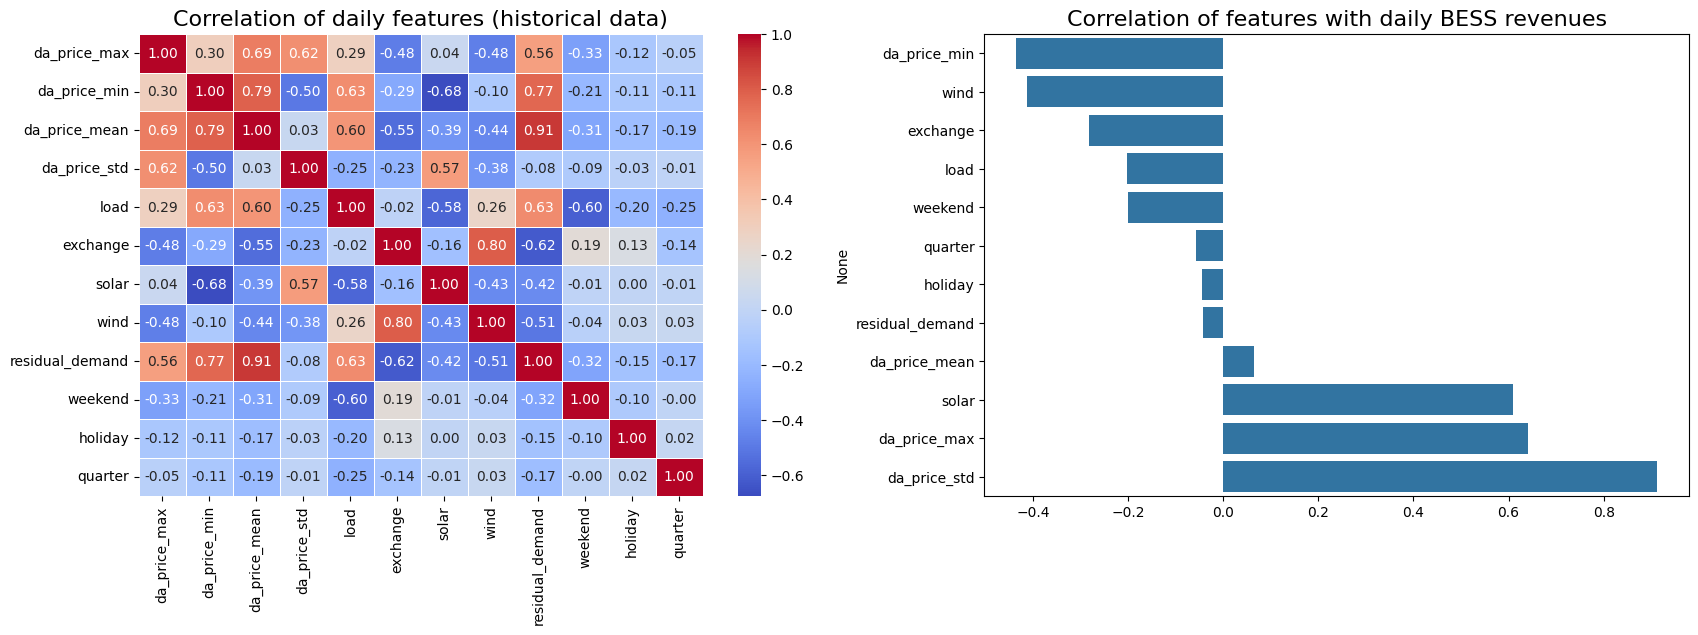

In [ ]:
fig_day, (ax0_day, ax1_day) = plt.subplots(1,2, figsize=(20, 6))

bess_corr = hist_df.corrwith(bess_benchmark).sort_values()
feat_corr = hist_df.corr()
sns.heatmap(feat_corr, ax=ax0_day, cmap="coolwarm", linewidths=0.5, annot=True, fmt=".2f", annot_kws={"size": 10})
ax0_day.set_title("Correlation of daily features (historical data)", fontsize=16)
sns.barplot(x=bess_corr.values, y=bess_corr.index, orient="h", ax=ax1_day)
ax1_day.set_title("Correlation of features with daily BESS revenues", fontsize=16)

### Rolling validation on training data

In [233]:
def rolling_validation(X:pd.DataFrame, 
                       y:pd.Series,
                       inp_length:int=7*12, # 3 months
                       pred_length:int=7, # 1 week
                       model_kwargs:dict={},  
                       ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Parameters:
    X: pd.DataFrame - input data
    y: pd.Series - target data
    inp_length: int - length of the context window in days (default: 7*12, i.e. 3 months)
    pred_length: int - length of the prediction window in days (default: 7, i.e. 1 week)
    model_kwargs: dict - keyword arguments for the model

    Performs a rolling validation, fitting the model to context_window and evaluating it 
    on pred_window. Returns a nested dictionary with the following structure:
    """
    
    model = xgb.XGBRegressor(**model_kwargs)
    y_prev = y.shift(pred_length).rename(f'{y.name}_{pred_length}lag')
    X = pd.concat([X, y_prev], axis=1).dropna()
    y = y[X.index]

    res_dict = {'datetime': [],
                'y_true': [], 
                'y_pred': []}
    
    feat_imp = []

    for train_start in range(0, len(X), pred_length):
        
        train_end = train_start + inp_length
        pred_end = train_end + pred_length
        
        if pred_end >= len(X):
            break
            
        print(f"Training {train_start}-{train_end-1} and testing {train_end}-{pred_end-1}") 
        X_train = X.iloc[train_start:train_end]
        y_train = y.iloc[train_start:train_end]
        X_test = X.iloc[train_end:pred_end]
        y_test = y.iloc[train_end:pred_end]
        model.fit(X_train, y_train)
        res = model.predict(X_test)
        ix = y_test.index
        res_dict['y_true'].extend(y_test.tolist())
        res_dict['y_pred'].extend(res.tolist())
        res_dict['datetime'].extend(ix)
        feat_imp.append(model.feature_importances_)
    
    results = pd.DataFrame().from_dict(res_dict).set_index('datetime')
    feature_importances = pd.DataFrame(feat_imp, columns=X.columns)
    
    return results, feature_importances

In [218]:
res_day, feat_imp_day = rolling_validation(X=hist_df, 
                                           y=bess_benchmark, 
                                           inp_length=7*12, pred_length=1, y_lags=1, 
                                           model_kwargs={'n_estimators': 100, 'max_depth': 3})

Training 0-83 and testing 84-84
Training 1-84 and testing 85-85
Training 2-85 and testing 86-86
Training 3-86 and testing 87-87
Training 4-87 and testing 88-88
Training 5-88 and testing 89-89
Training 6-89 and testing 90-90
Training 7-90 and testing 91-91
Training 8-91 and testing 92-92
Training 9-92 and testing 93-93
Training 10-93 and testing 94-94
Training 11-94 and testing 95-95
Training 12-95 and testing 96-96
Training 13-96 and testing 97-97
Training 14-97 and testing 98-98
Training 15-98 and testing 99-99
Training 16-99 and testing 100-100
Training 17-100 and testing 101-101
Training 18-101 and testing 102-102
Training 19-102 and testing 103-103
Training 20-103 and testing 104-104
Training 21-104 and testing 105-105
Training 22-105 and testing 106-106
Training 23-106 and testing 107-107
Training 24-107 and testing 108-108
Training 25-108 and testing 109-109
Training 26-109 and testing 110-110
Training 27-110 and testing 111-111
Training 28-111 and testing 112-112
Training 29-112

Text(0.5, 1.0, 'Most important features for prediction')

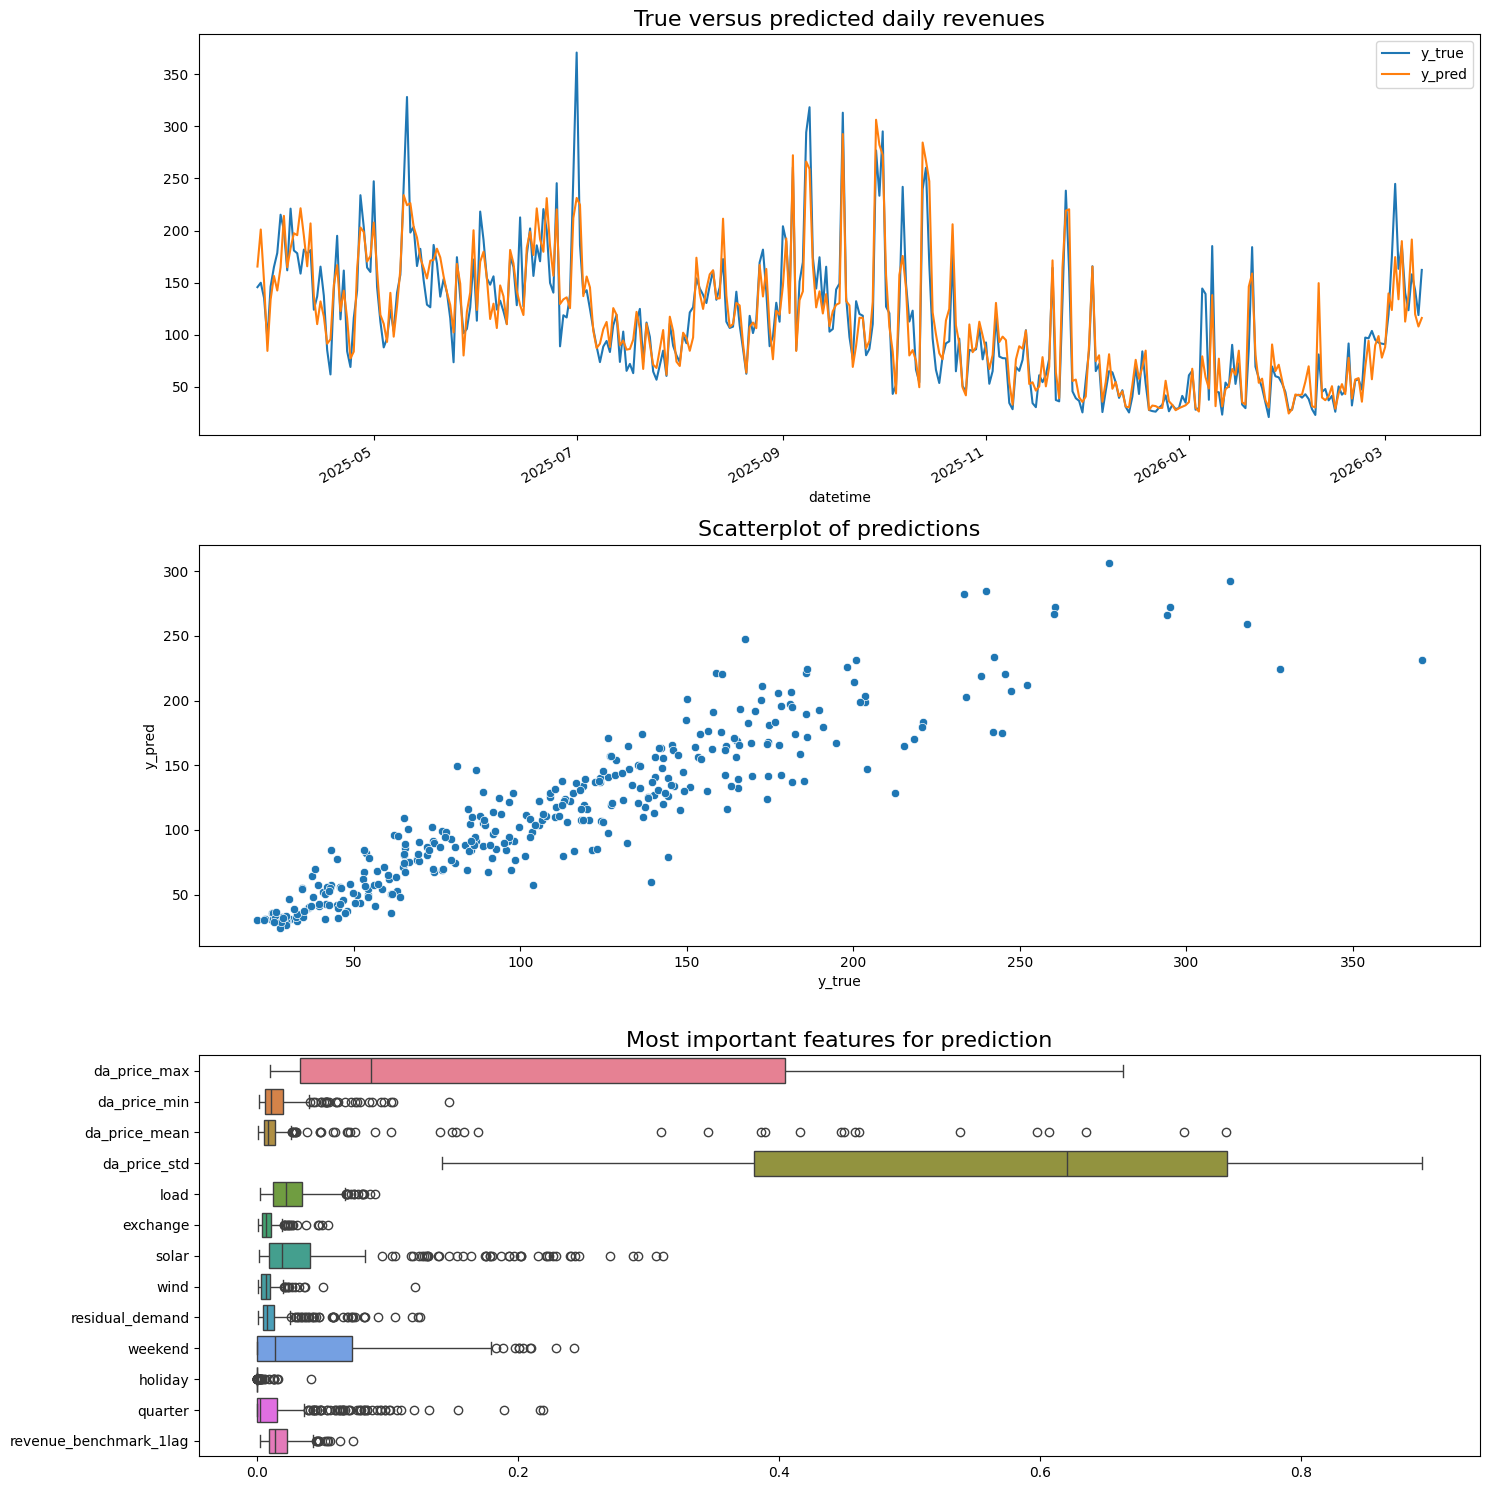

In [306]:
fig_day, (ax0_day, ax1_day, ax2_day) = plt.subplots(3, figsize=(15, 15), tight_layout=True)

res_day.plot(ax=ax0_day)
ax0_day.set_title("True versus predicted daily revenues", fontsize=16)
sns.scatterplot(res_day, x="y_true", y="y_pred", ax=ax1_day)
ax1_day.set_title("Scatterplot of predictions", fontsize=16)
sns.boxplot(feat_imp_day, orient="h", ax=ax2_day)
ax2_day.set_title("Most important features for prediction", fontsize=16)

### Weekly predictions


In [289]:
month_feat = ['da_price_mean', 'load', 'exchange', 'solar', 'wind']
X_week = hist_df[month_feat].resample('1W').mean()
X_week['quarter'] = X_week.index.quarter
X_week['weekofmonth'] = np.arange(len(X_week)) % 4

y_week = bess_benchmark.resample('1W').sum()

res_week_agg, feat_imp_week_agg = rolling_validation(X=X_week, 
                                                      y=y_week, 
                                                      inp_length=12, pred_length=1,
                                               model_kwargs={'n_estimators': 100, 'max_depth': 3})
res_week_agg = res_week_agg.rename(columns={'y_pred': 'y_pred_agg'})


Training 0-11 and testing 12-12
Training 1-12 and testing 13-13
Training 2-13 and testing 14-14
Training 3-14 and testing 15-15
Training 4-15 and testing 16-16
Training 5-16 and testing 17-17
Training 6-17 and testing 18-18
Training 7-18 and testing 19-19
Training 8-19 and testing 20-20
Training 9-20 and testing 21-21
Training 10-21 and testing 22-22
Training 11-22 and testing 23-23
Training 12-23 and testing 24-24
Training 13-24 and testing 25-25
Training 14-25 and testing 26-26
Training 15-26 and testing 27-27
Training 16-27 and testing 28-28
Training 17-28 and testing 29-29
Training 18-29 and testing 30-30
Training 19-30 and testing 31-31
Training 20-31 and testing 32-32
Training 21-32 and testing 33-33
Training 22-33 and testing 34-34
Training 23-34 and testing 35-35
Training 24-35 and testing 36-36
Training 25-36 and testing 37-37
Training 26-37 and testing 38-38
Training 27-38 and testing 39-39
Training 28-39 and testing 40-40
Training 29-40 and testing 41-41
Training 30-41 and t

In [292]:
res_week, feat_imp_week = rolling_validation(X=hist_df, 
                                             y=bess_benchmark, 
                                             inp_length=12*7, pred_length=7, 
                                             model_kwargs={'n_estimators': 100, 'max_depth': 3})

res_week = res_week.resample('1W').sum()
res_week = res_week_agg.join(res_week['y_pred'])


Training 0-83 and testing 84-90
Training 7-90 and testing 91-97
Training 14-97 and testing 98-104
Training 21-104 and testing 105-111
Training 28-111 and testing 112-118
Training 35-118 and testing 119-125
Training 42-125 and testing 126-132
Training 49-132 and testing 133-139
Training 56-139 and testing 140-146
Training 63-146 and testing 147-153
Training 70-153 and testing 154-160
Training 77-160 and testing 161-167
Training 84-167 and testing 168-174
Training 91-174 and testing 175-181
Training 98-181 and testing 182-188
Training 105-188 and testing 189-195
Training 112-195 and testing 196-202
Training 119-202 and testing 203-209
Training 126-209 and testing 210-216
Training 133-216 and testing 217-223
Training 140-223 and testing 224-230
Training 147-230 and testing 231-237
Training 154-237 and testing 238-244
Training 161-244 and testing 245-251
Training 168-251 and testing 252-258
Training 175-258 and testing 259-265
Training 182-265 and testing 266-272
Training 189-272 and testi

Text(0.5, 1.0, 'Most important features for prediction')

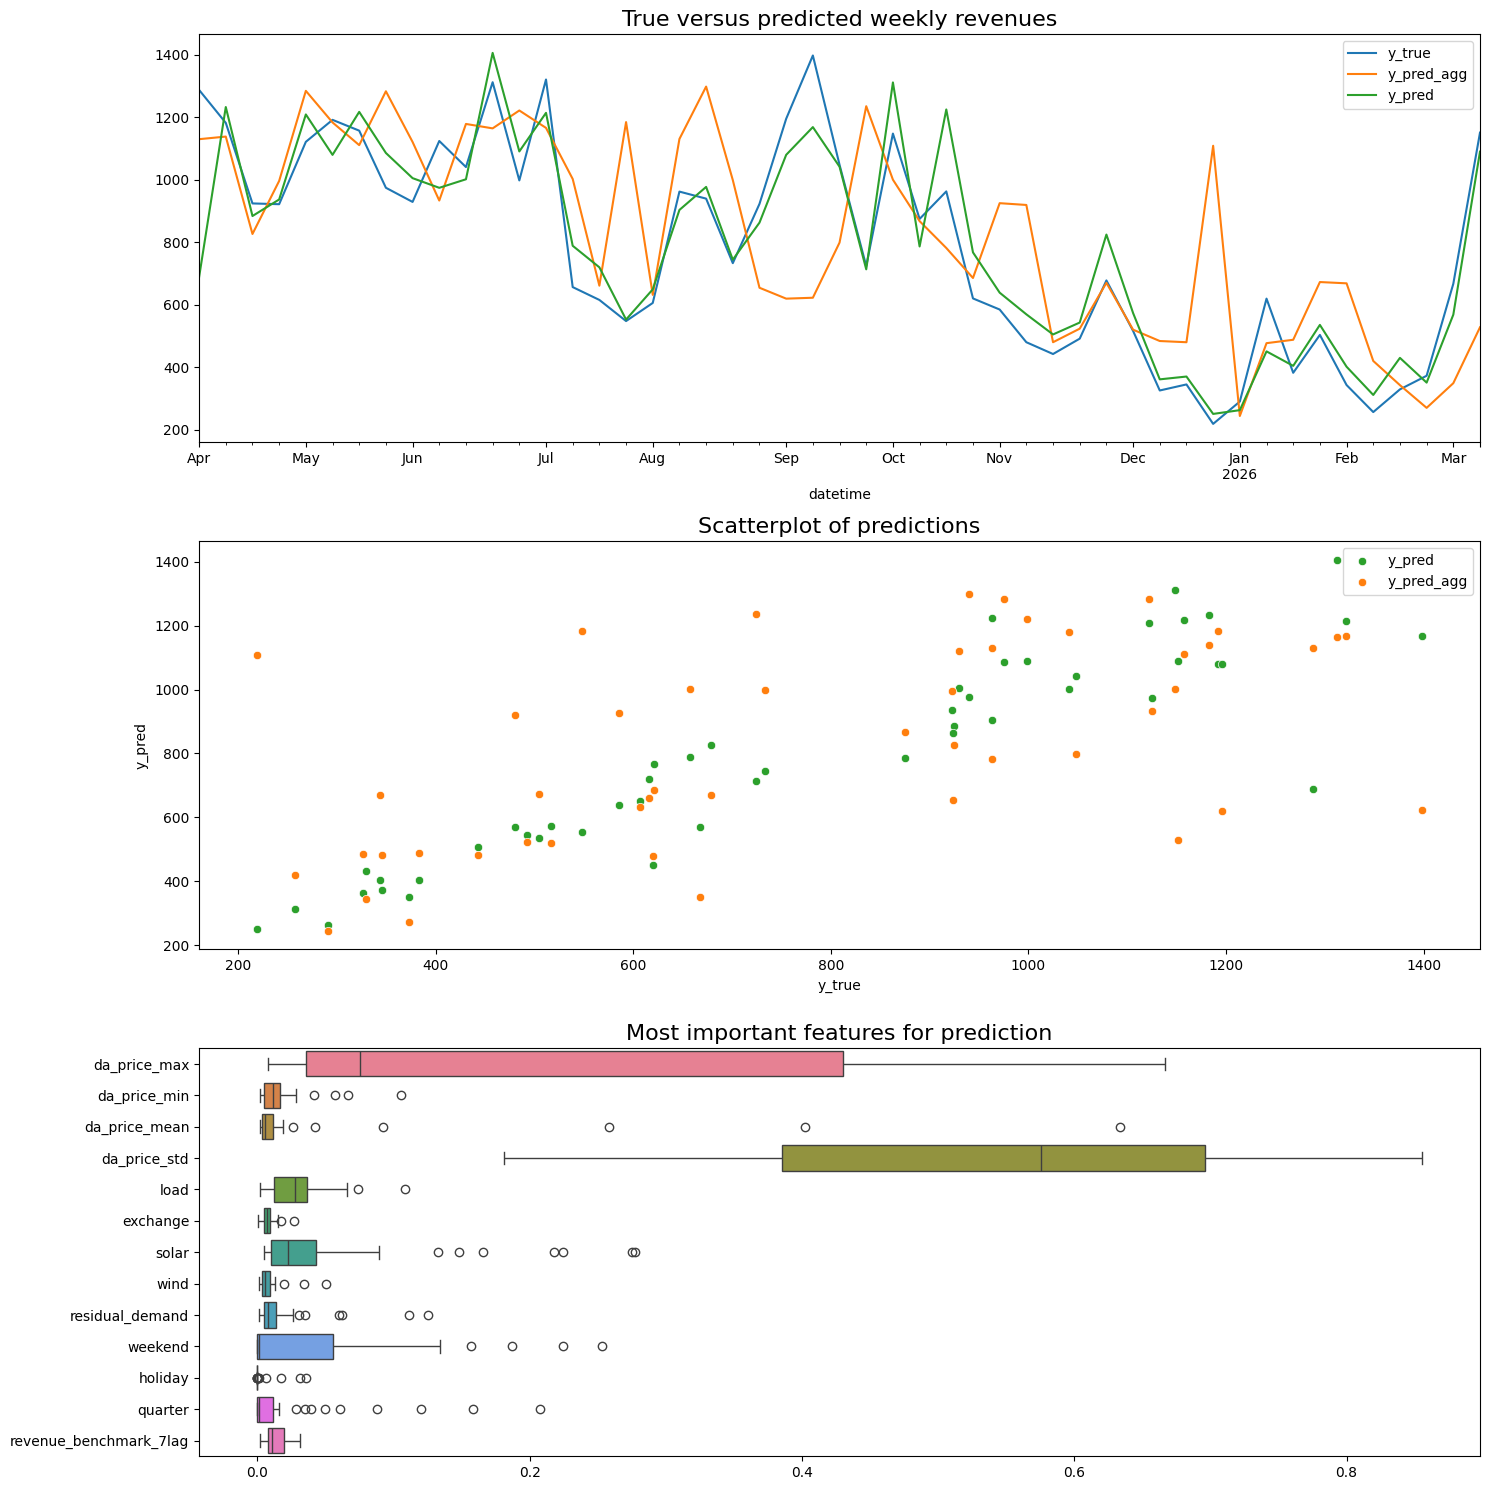

In [303]:
fig_week, (ax0_week, ax1_week, ax2_week) = plt.subplots(3, figsize=(15, 15), tight_layout=True)

res_week.plot(ax=ax0_week)
ax0_week.set_title("True versus predicted weekly revenues", fontsize=16)
sns.scatterplot(res_week, x="y_true", y="y_pred", ax=ax1_week, c='tab:green', label='y_pred')
sns.scatterplot(res_week, x="y_true", y="y_pred_agg", ax=ax1_week, c='tab:orange', label='y_pred_agg')
ax1_week.set_title("Scatterplot of predictions", fontsize=16)
sns.boxplot(feat_imp_week, orient="h", ax=ax2_week)
ax2_week.set_title("Most important features for prediction", fontsize=16)

### Monthly predictions

In [268]:
month_feat = ['da_price_mean', 'load', 'exchange', 'solar', 'wind']
X_month = hist_df[month_feat].resample('1ME').mean()
X_month['quarter'] = X_month.index.quarter

y_month = bess_benchmark.resample('1ME').sum()

res_month_agg, feat_imp_month_agg = rolling_validation(X=X_month, 
                                               y=y_month, 
                                               inp_length=3, pred_length=1,
                                               model_kwargs={'n_estimators': 100, 'max_depth': 3})
res_month_agg = res_month_agg.rename(columns={'y_pred': 'y_pred_agg'})


Training 0-2 and testing 3-3
Training 1-3 and testing 4-4
Training 2-4 and testing 5-5
Training 3-5 and testing 6-6
Training 4-6 and testing 7-7
Training 5-7 and testing 8-8
Training 6-8 and testing 9-9
Training 7-9 and testing 10-10
Training 8-10 and testing 11-11
Training 9-11 and testing 12-12


In [ ]:
res_month, feat_imp_month = rolling_validation(X=hist_df, 
                                               y=bess_benchmark, 
                                               inp_length=12*7, pred_length=30, 
                                               model_kwargs={'n_estimators': 100, 'max_depth': 3})

res_month = res_month.resample('1ME').sum()
res_month = res_month_agg.join(res_month['y_pred'])
res_month.index = res_month.index.format(date_format=r'%b/%y')

Training 0-89 and testing 90-119
Training 30-119 and testing 120-149
Training 60-149 and testing 150-179
Training 90-179 and testing 180-209
Training 120-209 and testing 210-239
Training 150-239 and testing 240-269
Training 180-269 and testing 270-299
Training 210-299 and testing 300-329
Training 240-329 and testing 330-359
Training 270-359 and testing 360-389


C:\Users\c.fusarbassini\AppData\Local\Temp\2\ipykernel_9728\1923472596.py:8: FutureWarning: DatetimeIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  res_month.index = res_month.index.format(date_format=r'%b/%y')


Text(0.5, 1.0, 'Most important features for predictions')

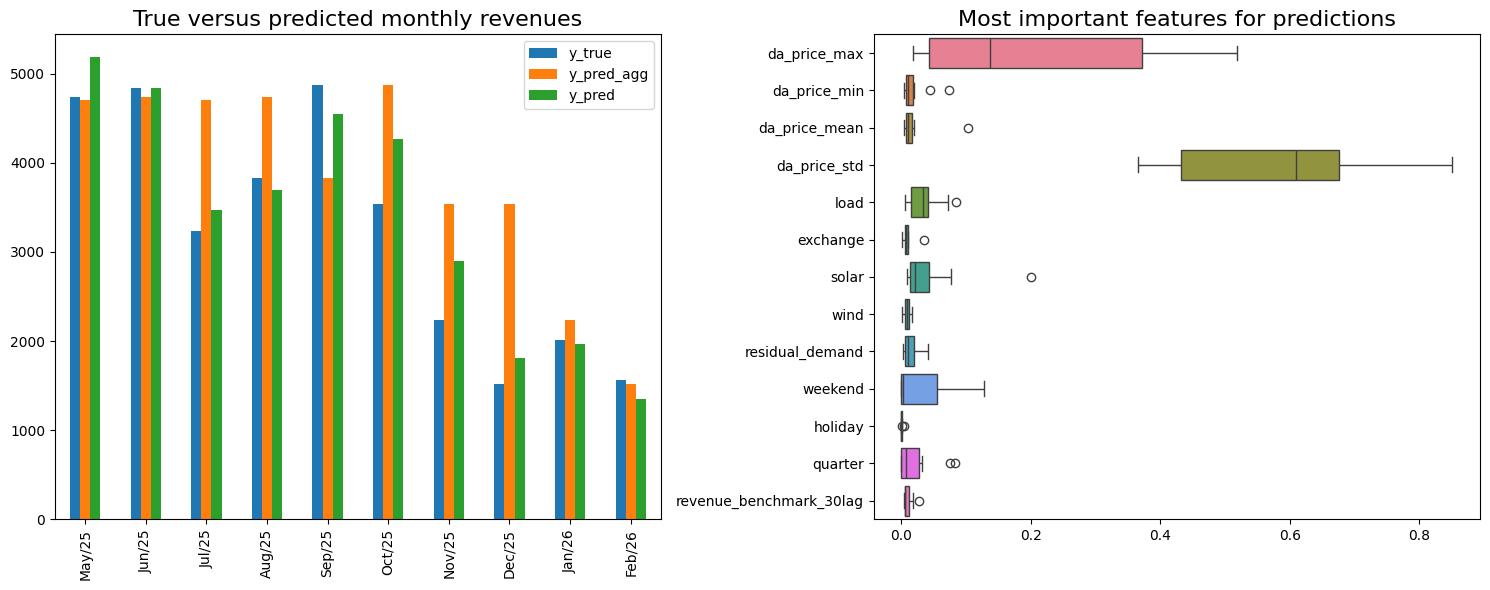

In [304]:
fig_month, (ax0_month, ax1_month) = plt.subplots(1,2, figsize=(15, 6), tight_layout=True)

res_month.plot(kind='bar', ax=ax0_month)
ax0_month.set_title("True versus predicted monthly revenues", fontsize=16)
sns.boxplot(feat_imp_month, orient="h", ax=ax1_month)
ax1_month.set_title("Most important features for predictions", fontsize=16)